# DBSCAN Benchmarking

In this notebook, we compare our custom-built DBSCAN (Density-Based Spatial Clustering of Applications with Noise) against the `scikit-learn` implementation. We will use the `make_moons` dataset to demonstrate how DBSCAN excels at finding non-spherical clusters and identifying outliers, a task where K-Means would typically fail.

In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
from time import time
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN as SklearnDBSCAN

# Import our custom modules
from classical_ml.unsupervised.dbscan import DBSCAN as CustomDBSCAN

Data shape: (400, 2)


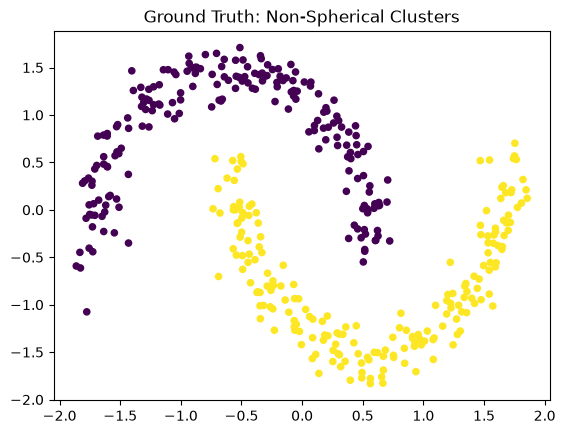

In [2]:
# 1. Generate Non-Spherical Data (Two intersecting half moons)
# We add a little bit of noise to make it realistic
X, y_true = make_moons(n_samples=400, noise=0.08, random_state=42)

# 2. Scale the data
# This is CRITICAL for DBSCAN because the 'eps' parameter relies on absolute distances
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Data shape: {X_scaled.shape}")

# Visualize the ground truth
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_true, cmap='viridis', s=20)
plt.title("Ground Truth: Non-Spherical Clusters")
plt.show()

1. Custom DBSCAN
Time Taken   : 1.12935 seconds



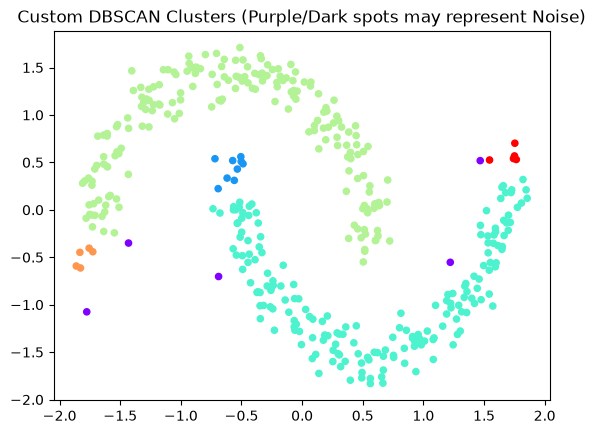

In [3]:
print("1. Custom DBSCAN")
start = time()

# Initialize DBSCAN with eps=0.2 and min_samples=5
custom_dbscan = CustomDBSCAN(eps=0.2, min_samples=5)
preds_custom = custom_dbscan.fit_predict(X_scaled)
time_custom = time() - start

print(f"Time Taken   : {time_custom:.5f} seconds\n")

# Plot custom predictions
# Note: Data points with label -1 are NOISE (outliers)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=preds_custom, cmap='rainbow', s=20)
plt.title("Custom DBSCAN Clusters (Purple/Dark spots may represent Noise)")
plt.show()

In [4]:
print("2. Scikit-Learn DBSCAN")
start = time()

# Match the parameters with our custom implementation
sk_dbscan = SklearnDBSCAN(eps=0.2, min_samples=5)
preds_sk = sk_dbscan.fit_predict(X_scaled)
time_sk = time() - start

print(f"Time Taken   : {time_sk:.5f} seconds\n")

# Let's verify if the predictions are identical (ignoring minor noise tie-breaking differences)
match_rate = np.mean(preds_custom == preds_sk)
print(f"Prediction Match Rate with Sklearn: {match_rate * 100:.2f}%")

2. Scikit-Learn DBSCAN
Time Taken   : 0.01350 seconds

Prediction Match Rate with Sklearn: 100.00%


## Conclusion
The visual results clearly demonstrate the power of **Density-Based Clustering**. 

Unlike K-Means, which assumes clusters are circular (spherical), our custom DBSCAN algorithm successfully navigated the complex geometry of the "moons" dataset by dynamically expanding the neighborhood region. It also effectively identified outliers (Noise) that didn't meet the density requirements.

The execution time for our pure Python implementation is understandably higher because the `_region_query` checks the Euclidean distance against every single data point in an unoptimized nested loop ($O(N^2)$ complexity). In contrast, `scikit-learn` uses highly optimized spatial indexing structures like **KD-Trees** or **Ball Trees** to find neighbors in $O(N \log N)$ time.